# Independent TESS Transit Analysis of TOI-1470

**Target:** TOI-1470 (TESS Input Catalog ID: TIC 284441182)

**Data source:** NASA TESS / MAST  

**Analysis environment:** Python / Jupyter Notebook  

**Primary tools:** Python, Lightkurve, Astropy, NumPy, Matplotlib  

## Research Objective

I will search TESS observations of TOI-1470 for periodic transit signals and characterize the signals that can be recovered from the available data.

I will initially perform the transit search independently of published planetary parameters and compare my results with the literature afterward.

## Analysis Log

### 2026-09-07
TOI-1470 chosen as the project target. Established the research questions and planned analysis workflow. MAST data review to come.

### 2026-09-10
Identified six available TESS SPOC 2-minute observations of TOI-1470 from Sectors 17, 18, 24, 58, 78, and 85.

The six light curves have been individually normalized and detrended. After the light curves were on a relatively common flux scale and the Signal-to-Noise Ratio was reasonably improved upon, the light curves were stitched together to help with further analysis.

The next stage is to prepare the combined dataset for a Box Least Squares transit search to determine periodicity.

In [2]:
import lightkurve as lk
from lightkurve import search_lightcurve
from lightkurve import search_targetpixelfile
from lightkurve import TessTargetPixelFile
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


# 1. TESS Data Audit

Before beginning the transit analysis, I first need to determine which TESS observations are available for TOI-1470 and the appropriate data products for this project.

I will prioritize TESS SPOC 2-minute cadence light curves because they provide the best pipeline-processed photometry available for this analysis.

I will document the available observations before selecting the data used for the main analysis.

In [3]:
search = lk.search_lightcurve('TIC 284441182', mission='TESS', author="SPOC", exptime=120)

search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 17,2019,SPOC,120,284441182,0.0
1,TESS Sector 18,2019,SPOC,120,284441182,0.0
2,TESS Sector 24,2020,SPOC,120,284441182,0.0
3,TESS Sector 58,2022,SPOC,120,284441182,0.0
4,TESS Sector 78,2024,SPOC,120,284441182,0.0
5,TESS Sector 85,2024,SPOC,120,284441182,0.0


## Available SPOC Observations

The search above identified 6 TESS SPOC data products for TOI-1470 at a 2-minute cadence. 6 data products is a fairly manageable amount of data to analyze. These observations will be used as the primary dataset for the transit analysis.

The sector information will be retained as individual TESS sectors can have different levels of systematics and data quality. Combining the data products is a key analysis step as the data products are not interchangeable.

In [4]:
search.table

intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max,exptime,distance,obsID,obs_collection_products,dataproduct_type_products,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project_products,prvversion,proposal_id_products,productFilename,size,parent_obsid,dataRights_products,calib_level_products,filters_products,author,mission,#,year,sort_order
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,s,arcsec,,,,,,,,,,,,,,,,,,,,,,,,
str7,str4,str4,str10,str4,str4,str7,str9,str1,str52,float64,float64,str10,str14,int64,float64,float64,float64,str7,float64,float64,str1,float64,str6,str1,int64,str46,str1,str79,str6,bool,float64,str9,str10,float64,float64,float64,float64,str9,str4,str10,str33,str1,str81,str7,str28,str7,str1,str4,str21,str6,str63,int64,str9,str6,int64,str4,str4,object,int64,int64,int64
science,TESS,SPOC,Photometer,TESS,TESS,OPTICAL,284441182,--,tess2019279210107-s0017-0000000284441182-0161-s,10.0887087707778,61.2136262085634,timeseries,"Ricker, George",3,58764.186217291666,58789.18103490741,120.0,OPTICAL,600.0,1000.0,--,58818.3333334,N/A,--,17,CIRCLE 10.08870877 61.21362621 0.00138889,--,mast:TESS/product/tess2019279210107-s0017-0000000284441182-0161-s_lc.fits,PUBLIC,False,nan,27554873,1099416557,600.0,1000.0,120,0.0,27554873,TESS,timeseries,Light curves,S,mast:TESS/product/tess2019279210107-s0017-0000000284441182-0161-s_lc.fits,SCIENCE,Minimum Recommended Products,LC,--,SPOC,f3590893ce,N/A,tess2019279210107-s0017-0000000284441182-0161-s_lc.fits,1831680,27554873,PUBLIC,3,TESS,SPOC,TESS Sector 17,0,2019,1
science,TESS,SPOC,Photometer,TESS,TESS,OPTICAL,284441182,--,tess2019306063752-s0018-0000000284441182-0162-s,10.0887087707778,61.2136262085634,timeseries,"Ricker, George",3,58790.15881918981,58814.516834525464,120.0,OPTICAL,600.0,1000.0,--,58833.3333334,N/A,--,18,CIRCLE 10.08870877 61.21362621 0.00138889,--,mast:TESS/product/tess2019306063752-s0018-0000000284441182-0162-s_lc.fits,PUBLIC,False,nan,27585662,1147871959,600.0,1000.0,120,0.0,27585662,TESS,timeseries,Light curves,S,mast:TESS/product/tess2019306063752-s0018-0000000284441182-0162-s_lc.fits,SCIENCE,Minimum Recommended Products,LC,--,SPOC,spoc-5.0.97-20230811,N/A,tess2019306063752-s0018-0000000284441182-0162-s_lc.fits,1785600,27585662,PUBLIC,3,TESS,SPOC,TESS Sector 18,1,2019,1
science,TESS,SPOC,Photometer,TESS,TESS,Optical,284441182,--,tess2020106103520-s0024-0000000284441182-0180-s,10.0887087707778,61.2136262085634,timeseries,"Ricker, George",3,58955.29041345,58981.77640903,120.0,Optical,600.0,1000.0,--,59001.0,N/A,--,24,CIRCLE ICRS 10.08870877 61.21362621 0.00138889,--,mast:TESS/product/tess2020106103520-s0024-0000000284441182-0180-s_lc.fits,PUBLIC,False,nan,27405583,70395443,600.0,1000.0,120,0.0,27405583,TESS,timeseries,Light curves,S,mast:TESS/product/tess2020106103520-s0024-0000000284441182-0180-s_lc.fits,SCIENCE,Minimum Recommended Products,LC,--,SPOC,b9bb72fe01,N/A,tess2020106103520-s0024-0000000284441182-0180-s_lc.fits,1938240,27405583,PUBLIC,3,TESS,SPOC,TESS Sector 24,2,2020,1
science,TESS,SPOC,Photometer,TESS,TESS,Optical,284441182,--,tess2022302161335-s0058-0000000284441182-0247-s,10.0887087707778,61.2136262085634,timeseries,"Ricker, George",3,59881.831892870374,59909.55105555555,120.0,Optical,600.0,1000.0,--,59928.0,N/A,--,58,CIRCLE 10.08870877 61.21362621 0.00138889,--,mast:TESS/product/tess2022302161335-s0058-0000000284441182-0247-s_lc.fits,PUBLIC,False,nan,104653775,820541490,600.0,1000.0,120,0.0,104653775,TESS,timeseries,Light curves,S,mast:TESS/product/tess2022302161335-s0058-0000000284441182-0247-s_lc.fits,SCIENCE,Minimum Recommended Products,LC,--,SPOC,70cc9b4d91,N/A,tess2022302

## Downloading the selected light curves

I will now download the available SPOC light curves identified above. The raw downloaded files will remain outside of the GitHub repository, but the notebook will still document the observations and analysis performed on the data files.

In [5]:
lc_collection = search.download_all()

lc_collection

LightCurveCollection of 6 objects:
    0: <TessLightCurve LABEL="TIC 284441182" SECTOR=17 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 284441182" SECTOR=18 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 284441182" SECTOR=24 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 284441182" SECTOR=58 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 284441182" SECTOR=78 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 284441182" SECTOR=85 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>

# 2. Initial Light-Curve Inspection

Before detrending or searching for transits, I will inspect the individual TESS observations.

This allows me to identify differences between sectors, instrumental trends, and other features that could affect the later transit search.

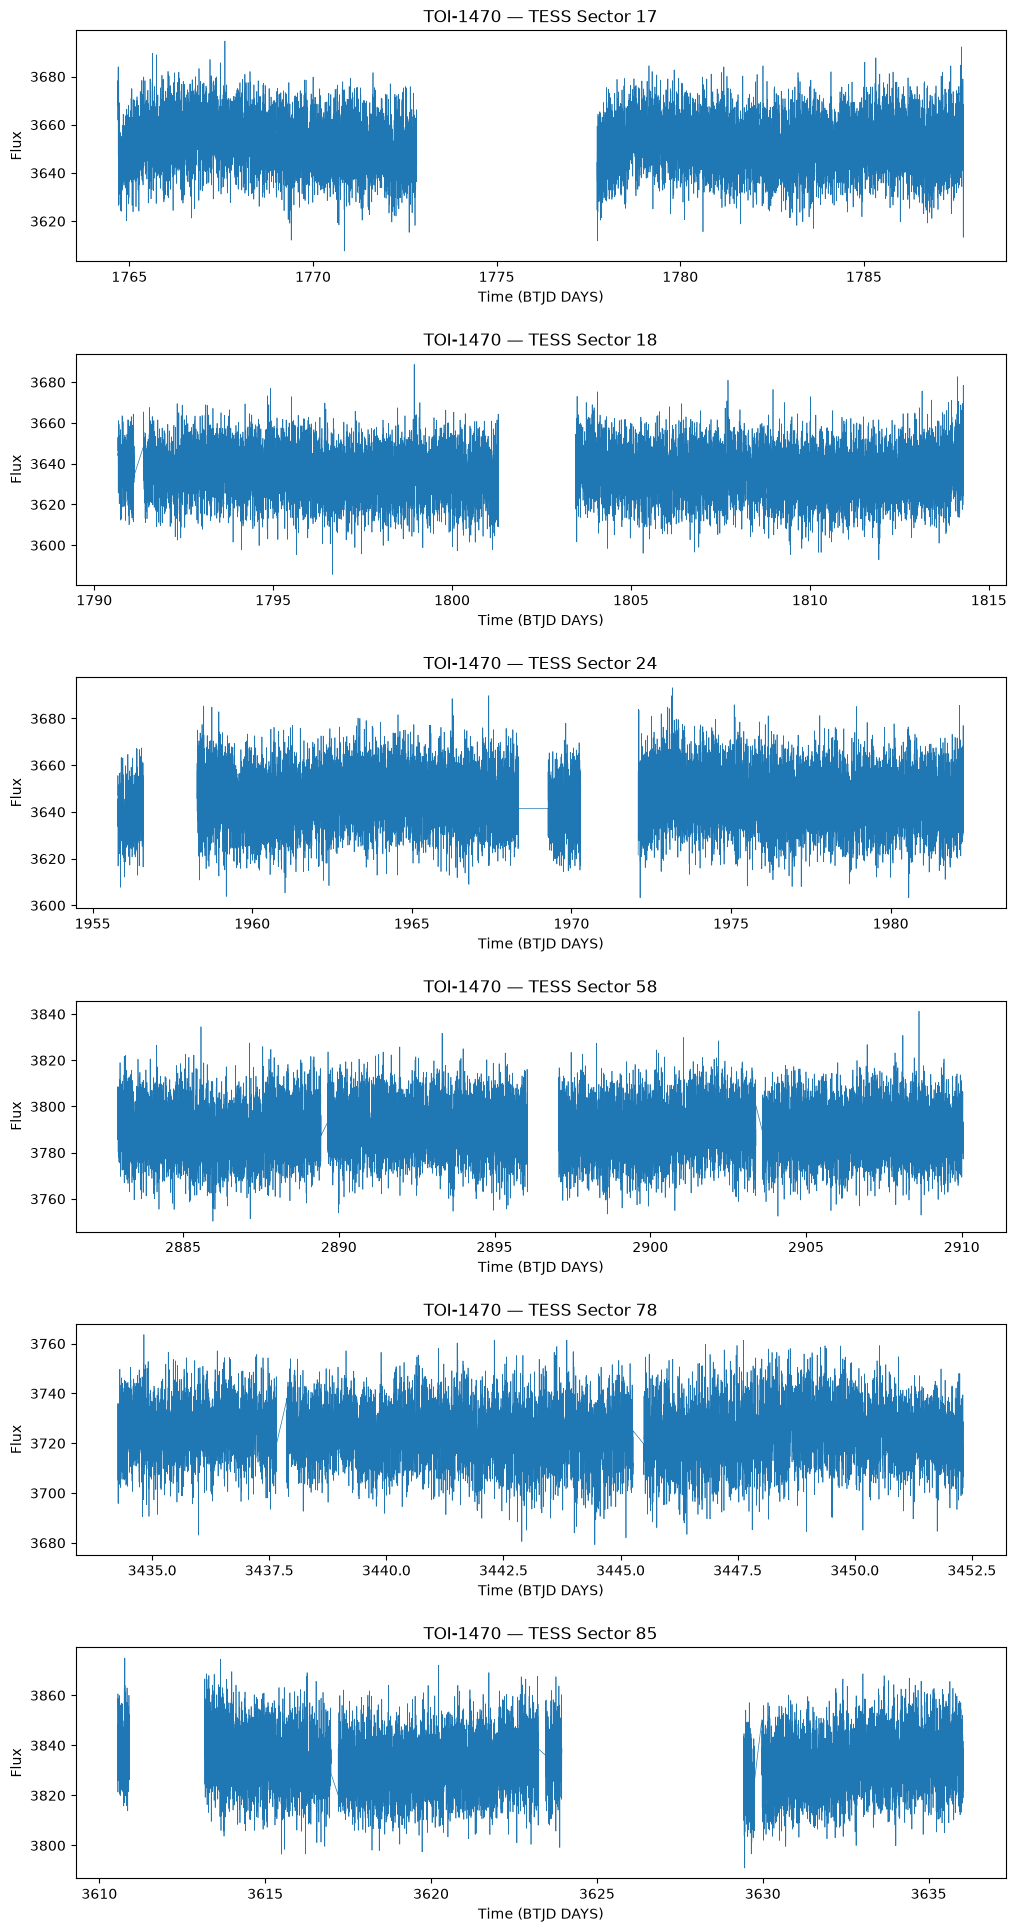

In [6]:
fig, axes = plt.subplots(len(lc_collection), 1, figsize=(12, 4 * len(lc_collection)), squeeze=False)


for ax, lc in zip(axes.flatten(), lc_collection):
    sector = lc.meta.get("SECTOR", "Unknown")
    
    ax.plot( lc.time.value, lc.flux, linewidth=0.5)
    
    ax.set_title(f"TOI-1470 — TESS Sector {sector}")
    ax.set_xlabel("Time (BTJD DAYS)")
    ax.set_ylabel("Flux")
    
plt.subplots_adjust(hspace=0.4)
plt.show()

## Inital Observation

For the above plots we can observe that the light curves exhibit a somewhat stable baseline flux per light curve. Given the high scatter and lack of clear periodic structures, it would be mostly speculative to determine any transits within the light curves as the data is currently, that's why further analysis and data manipulation is needed to help determine transits and periodicity.

Within each raw light curve, there are distinct instrumental gaps typically in the middle of the light curve. For sector 78, the light curve does not exhibit any instrumental gaps, while sector 24 and sector 85 exhibit two instrumental gaps. 

These gaps represent a scheduled spacecraft data downlink where the TESS temporarily ceases science operations to transmit data to Earth. These gaps are mathematically encoded as 'NaN' values within the flux arrays. Any other (typically smaller) instrumental gaps are not treated the same way, as these gaps may be caused by the TESS firing its thrusters.

To note: The diagonal lines between smaller gaps ARE NOT data, they are simply interpolation artifacts caused by software blindly drawing a line between the two vastly different data points.

# 3. Preparing the Photometric Data Before Combining


For the initial transit search, I will use the SPOC PDCSAP flux rather than raw SAP as SPOC's PDCSAP tries to remove instrumental variations while preserving signals like transits.  Each sector will be normalized independently so that differences in the absolute flux level between observations do not affect the combined light curve.


I will initially preserve the individual sectors rather than immediately applying a single detrending operation to the entire dataset. For the light curves, it is important to remove the 'NaN' discussed in **Initial Observation** and to normalize the light curves onto a shared baseline before proceding with further analysis.

In [7]:
normalized_lcs = []

for lc in lc_collection:
    lc = lc.remove_nans()
    lc = lc.normalize()
    normalized_lcs.append(lc)

normalized_lcs

[<TessLightCurve length=12841 LABEL="TIC 284441182" SECTOR=17 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
        time             flux      ...   pos_corr1      pos_corr2   
                                   ...      pix            pix      
        Time           float32     ...    float32        float32    
 ------------------ -------------- ... -------------- --------------
  1764.687712383559  1.0043811e+00 ...  3.3258442e-02 -8.1420066e-03
 1764.6891013165487  1.0071626e+00 ...  3.3778787e-02 -9.4064139e-03
 1764.6904902493052  1.0026810e+00 ...  2.7451236e-02 -8.8116396e-03
 1764.6918791820624  1.0039841e+00 ...  3.8284596e-02 -3.6782955e-03
 1764.6932681148198  1.0055077e+00 ...  3.2982599e-02 -9.4566680e-03
 1764.6946570475764  1.0049841e+00 ...  2.9958306e-02 -9.2295893e-03
 1764.6960459803329  1.0087278e+00 ...  3.2613296e-02 -9.3231760e-03
 1764.6974349130896  1.0006988e+00 ...  3.3865102e-02 -8.6848214e-03
 1764.6988238458462  9.9854100e-01 ...  3.6753248e-02 -3.4347884e-03
    

## Normalized Light Curves

I normalized each TESS sector independently so that the observations are placed on a common relative-flux scale.

Normalization changes the flux scale but does not remove the longer-timescale trends or other systematic variations present in the observations. Those effects will be addressed separately before the transit search.

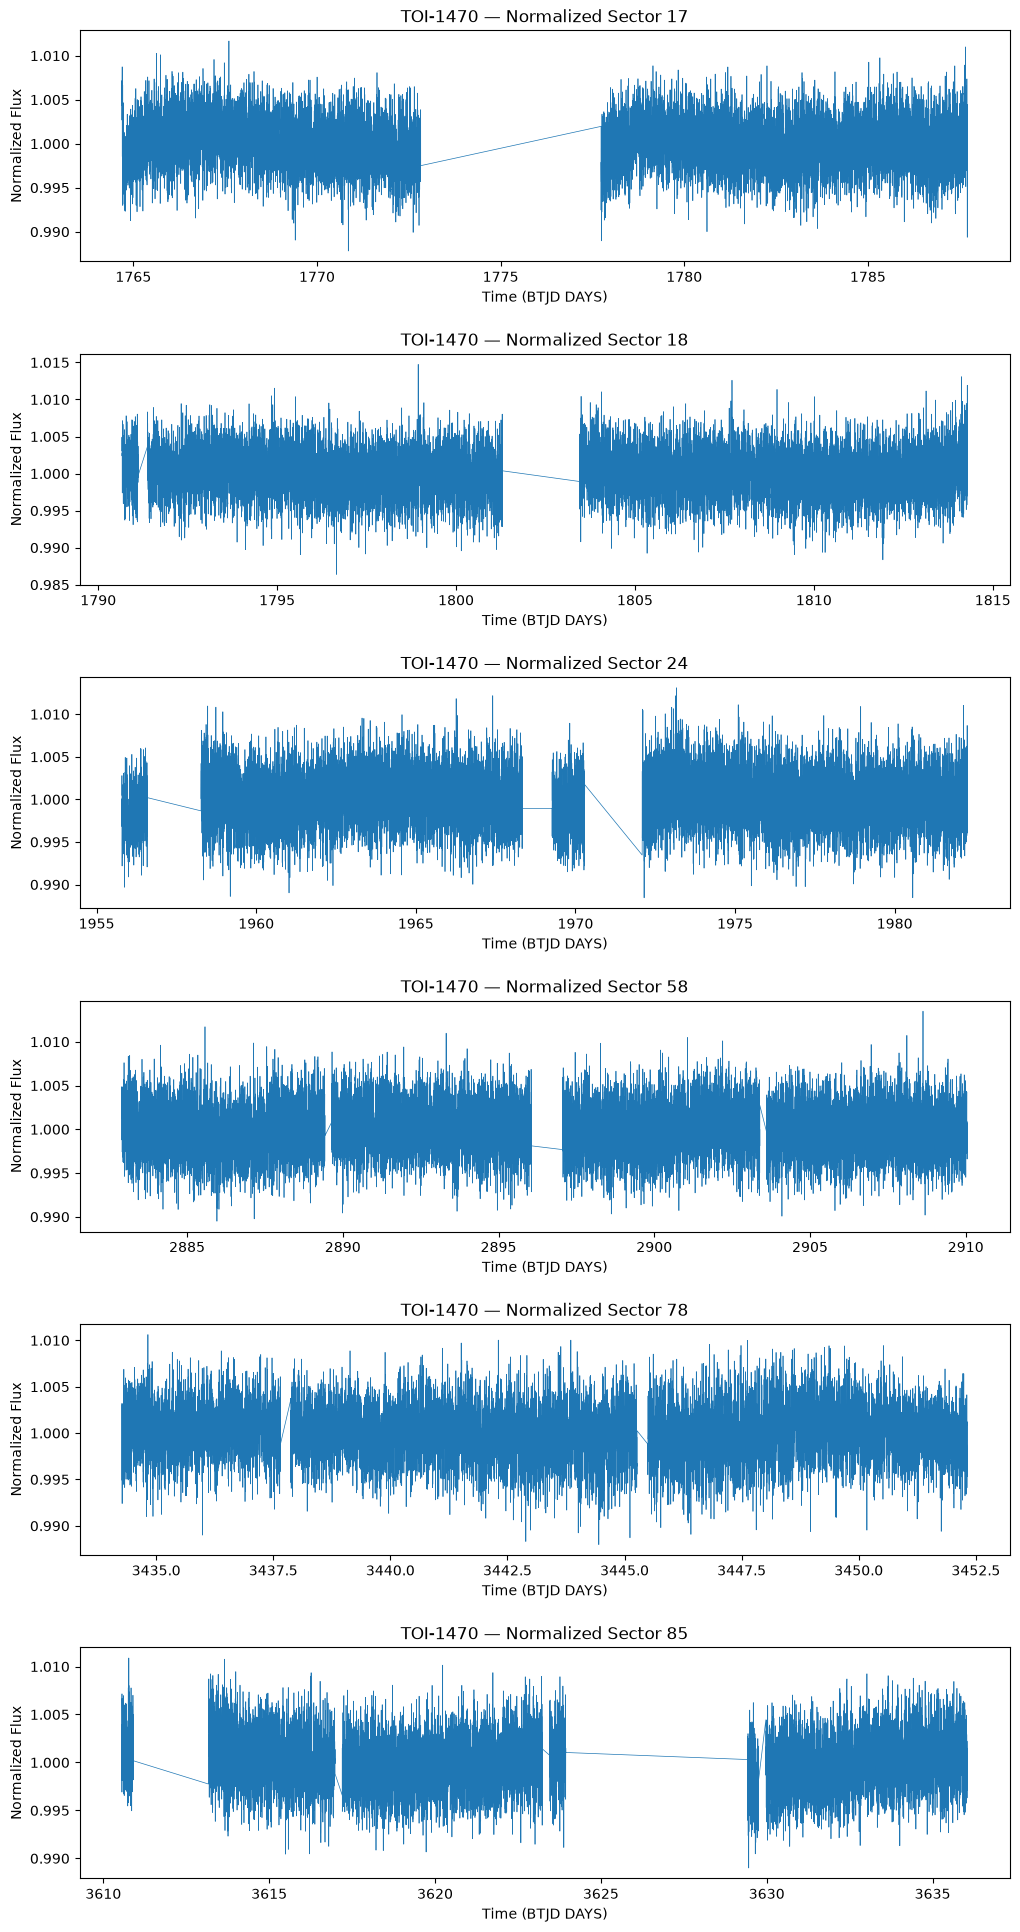

In [22]:
fig, axes = plt.subplots(len(normalized_lcs), 1, figsize=(12, 4 * len(normalized_lcs)), squeeze=False)


for ax, lc in zip(axes.flatten(), normalized_lcs):
    sector = lc.meta.get("SECTOR", "Unknown")
    
    ax.plot( lc.time.value, lc.flux, linewidth=0.5)
    
    ax.set_title(f"TOI-1470 — Normalized Sector {sector}")
    ax.set_xlabel("Time (BTJD DAYS)")
    ax.set_ylabel("Normalized Flux")
    
plt.subplots_adjust(hspace=0.4)
plt.show()

## Normalization Observation

We can observe that the plots of the normalized light curves look nearly identical to the plots generate initially. This is because our normalization does not alter any astrophysical signals. Instead, they standardize the data and scale to ensure the multiple sectors can be stitched together without running into any errors or offsets. We can observe that all of the light curves now reside within ~1.0 flux. This is visible proof that the light curves are on a common flux scale and that we were able to successfully normalize the plots.

One thing that is apparent to use is that those larger instrumental gaps now have the same line connection as the smaller gaps within each light curve, this supports the analysis within the **Initial Observation**.

# 4. Detrending the Individual TESS Sectors

The normalized light curves still contain variations and instrumental structure that could interfere with the detection of short-duration transit signals.

Therefore I will detrend each TESS sector independently using a Savitzky–Golay filter. Treating the sectors independently avoids fitting a single trend across the large gaps between observations.

For the initial analysis, I will use a 1001-cadence window. At 2-minute cadence, that is around a 33 hour window, which is much longer than a typical planetary transit and should allow the shorter transit features to remain in the light curve.

The detrending parameters will be tested later to determine whether the recovered transit signals are consistent across reasonable choices of filter-window size.

A small number of extreme photometric measurements can interfere with the transit search. I will remove only strong outliers while retaining the majority of the original measurements so that genuine transit signals are not unnecessarily clipped. We can do this by using the remove_outliers command.

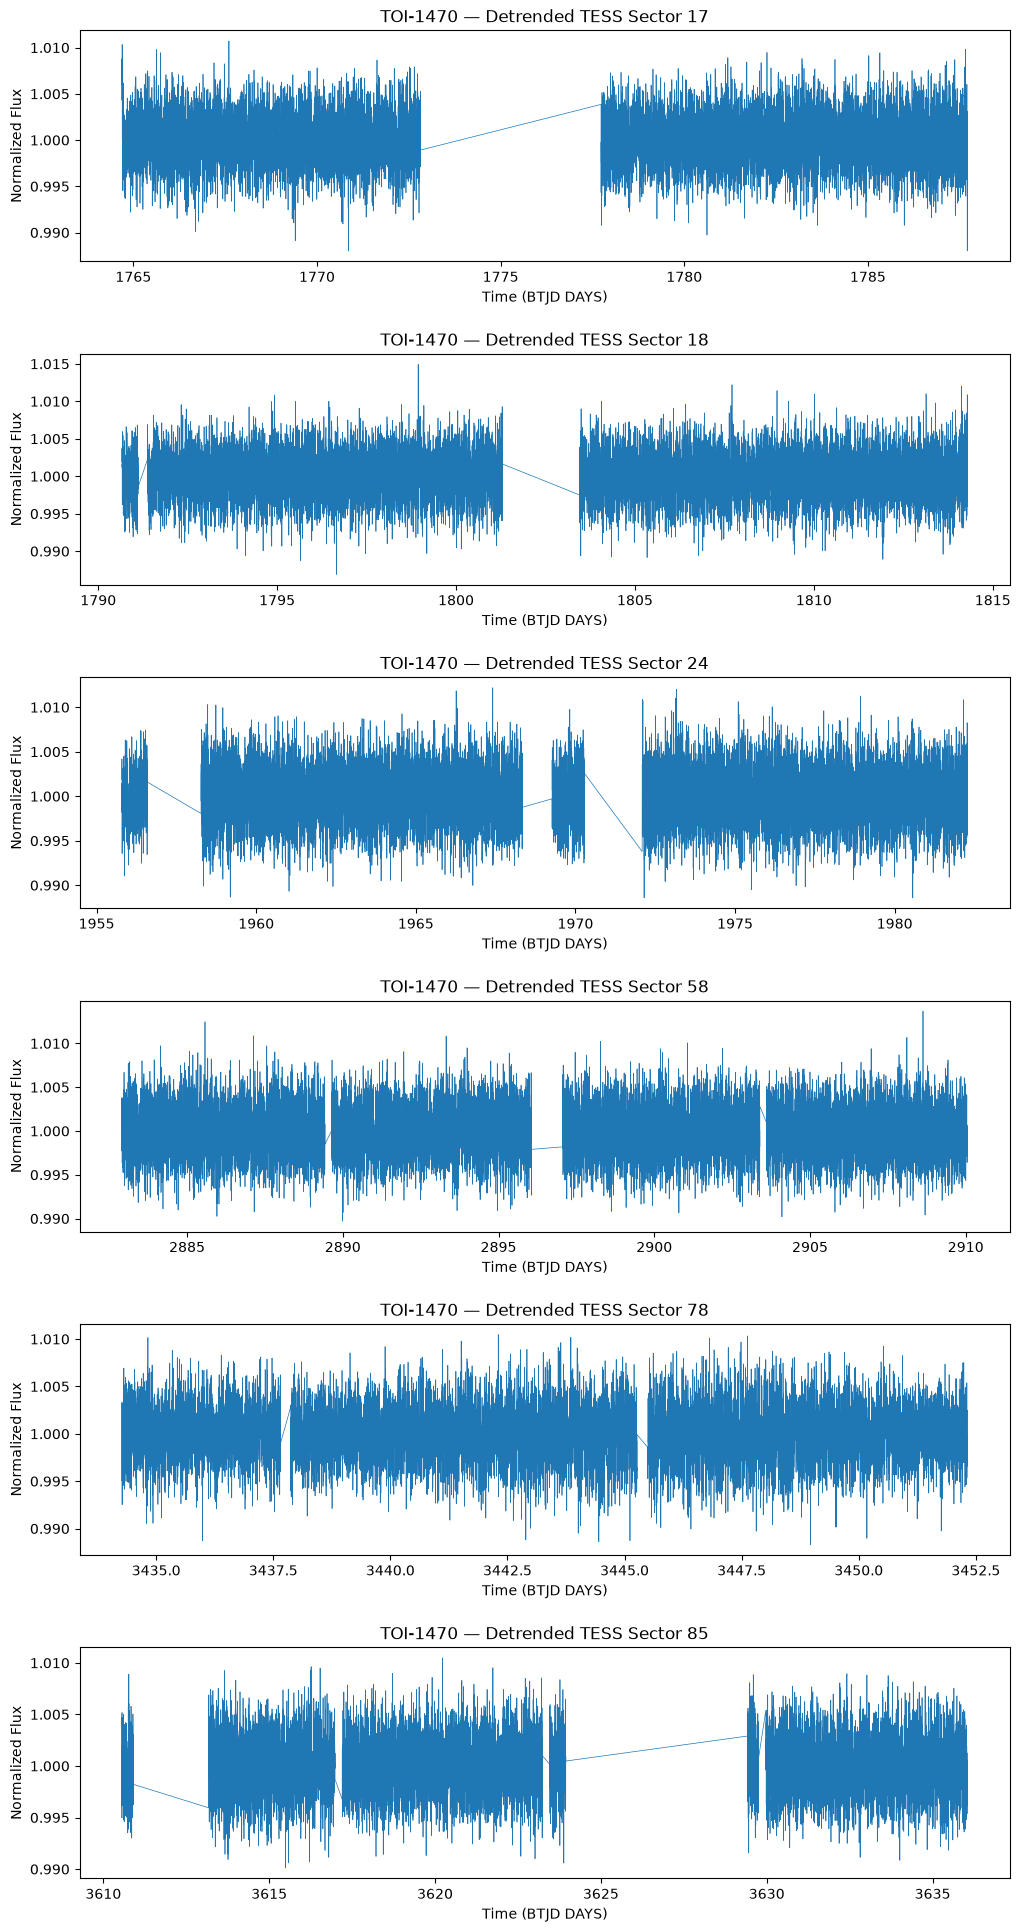

In [35]:
detrended_lcs = []

for lc in normalized_lcs:
    detrended = lc.flatten(
        window_length=1001,
        polyorder=2,
        break_tolerance=5,
        niters=1
    )
    
    detrended_lcs.append(detrended)

cleaned_lcs = []

for lc in detrended_lcs:
    cleaned = lc.remove_outliers(sigma=6)
    cleaned_lcs.append(cleaned)

cleaned_lcs


fig, axes = plt.subplots(len(cleaned_lcs), 1, figsize=(12, 4 * len(cleaned_lcs)), squeeze=False)

for ax, lc in zip(axes.flatten(), cleaned_lcs):
    sector = lc.meta.get("SECTOR", "Unknown")
    
    ax.plot(lc.time.value, lc.flux, linewidth=0.5)
    
    ax.set_title(f"TOI-1470 — Detrended TESS Sector {sector}")
    ax.set_xlabel("Time (BTJD DAYS)")
    ax.set_ylabel("Normalized Flux")

plt.subplots_adjust(hspace=0.4)
plt.show()

# 6. Combined TESS Light Curve

After independently normalizing, detrending, and cleaning the individual TESS sectors, I will combine the observations into a single light curve to use for the transit search.

Stitching will bring together the available measurements and does not create observations within gaps between any gaps.

If we want to view the plot without diagonal lines connecting everything, we can use a scattor plot instead of the regular plot we have been using thus far.

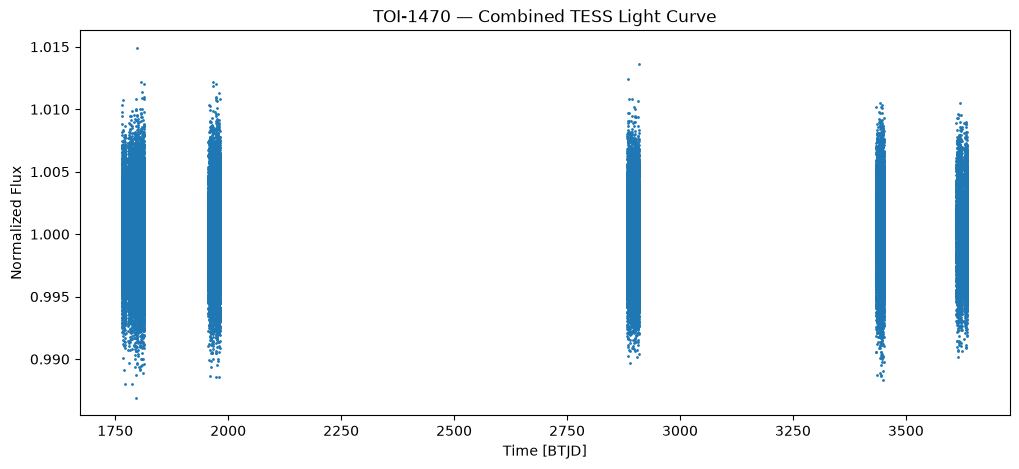

In [37]:
combined_lc = lk.LightCurveCollection(cleaned_lcs).stitch()

combined_lc

plt.figure(figsize=(12, 5))

plt.scatter(
    combined_lc.time.value,
    combined_lc.flux,
    s=1
)

plt.xlabel("Time [BTJD]")
plt.ylabel("Normalized Flux")
plt.title("TOI-1470 — Combined TESS Light Curve")

plt.show()

## Initial Stitching Observation
When first observing this plot you might think to yourself "Wow! That looks really bad!" But our data hasn't become corrupted or mismanaged up to this point, if anything, the data is looking exactly how it should. This is how stitching is supposed to look, we have placed the six normalized light curves onto the same common time axis. This serves to show the breaks in time between each observation of TOI-1470.

Also at first I thought "This is only five light curves, where did the sixth one go!" But the sector 17 and sector 18 light curves reside perfectly next to each other (on the leftmost part of our plot), meaning that TOI-1470 was being still being observed when TESS switched viewing from sector 17 to sector 18.